<a href="https://colab.research.google.com/github/AhmadNurRofik/UAS_rofik_23.11.5475/blob/main/UAS_rofik_23.11.5475.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Identitas Mahasiswa:**
* Nama: Ahmad Nur Rofik
* Nim: 23.11.5475
* Kelas: IF02

**Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

print("Library berhasil di-load.")

Library berhasil di-load.


**Load & Profiling Dataset**

In [ ]:
df = pd.read_csv('/content/Crop_recommendation.csv')

print("=== INFO DATASET ===")
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
print("\n=== CONTOH DATA ===")
display(df.head())


=== CONTOH DATA ===


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())


=== STATISTIK DESKRIPTIF ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())


=== CEK MISSING VALUE ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
print("\n=== CEK DUPLIKAT ===")
print("Jumlah duplikat:", df.duplicated().sum())


=== CEK DUPLIKAT ===
Jumlah duplikat: 0


**Data Cleaning**

In [ ]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplikat dihapus.")
else:
    print("Tidak ada duplikat.")

Tidak ada duplikat.


**Pisahkan Fitur & Target**

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribusi kelas target:")
print(y.value_counts())

Shape X: (2200, 7)
Shape y: (2200,)

Distribusi kelas target:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


**EDA (Visualisasi)**

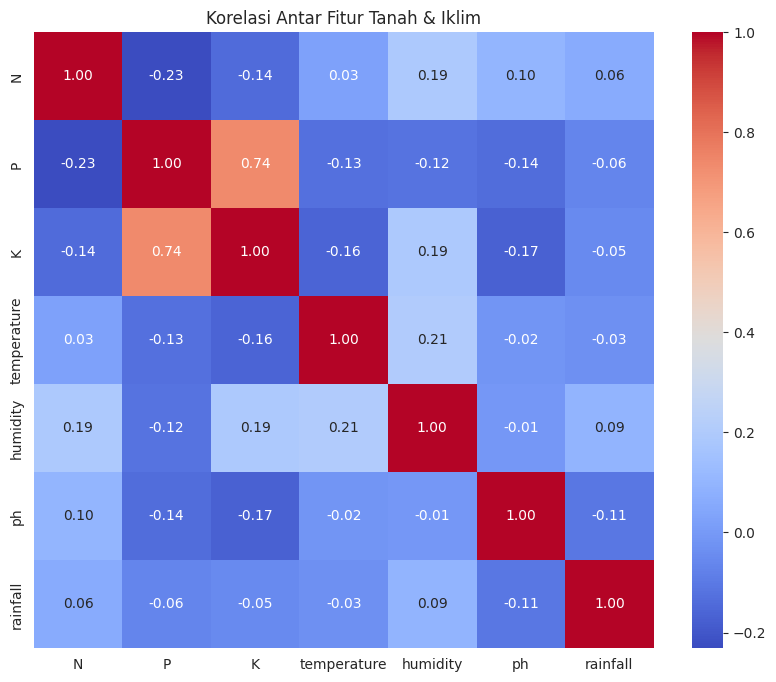

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Fitur Tanah & Iklim")
plt.show()

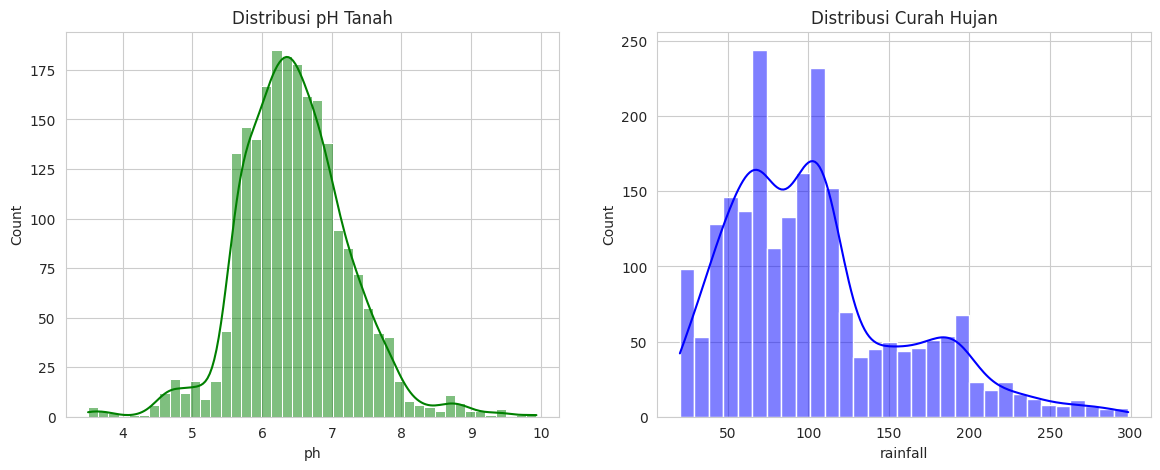

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['ph'], kde=True, color='green')
plt.title("Distribusi pH Tanah")

plt.subplot(1, 2, 2)
sns.histplot(df['rainfall'], kde=True, color='blue')
plt.title("Distribusi Curah Hujan")

plt.show()

**Feature Selection (ANOVA)**

In [ ]:
selector = SelectKBest(score_func=f_classif, k='all')
fit = selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Fitur': X.columns,
    'Score': fit.scores_
}).sort_values(by='Score', ascending=False)

print("=== RANKING FITUR ===")
display(feature_scores)

=== RANKING FITUR ===


,Fitur,Score
2,K,27238.362067
4,humidity,3103.708891
1,P,1885.657859
0,N,897.568186
6,rainfall,605.527966
3,temperature,102.186981
5,ph,60.344034


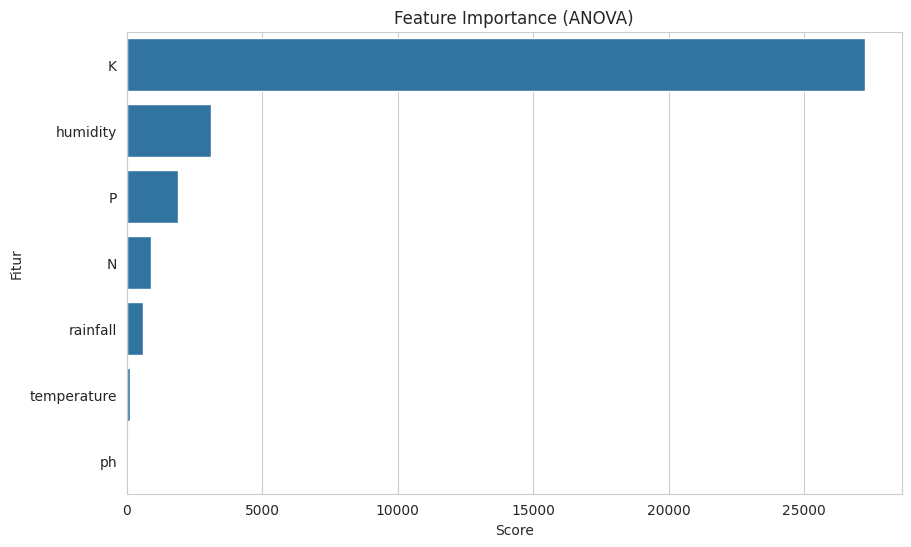

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Fitur', data=feature_scores)
plt.title("Feature Importance (ANOVA)")
plt.show()

**Terapkan Feature Selection ke Model**

In [ ]:
selected_features = feature_scores.head(5)['Fitur'].tolist()

X_selected = X[selected_features]

print("Fitur terpilih:", selected_features)
print("Shape X setelah seleksi:", X_selected.shape)

Fitur terpilih: ['K', 'humidity', 'P', 'N', 'rainfall']
Shape X setelah seleksi: (2200, 5)


**Split Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

Data training : (1760, 5)
Data testing  : (440, 5)


**Training Model**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Training model Random Forest...")
rf_model.fit(X_train, y_train)
print("Training selesai.")

Training model Random Forest...
Training selesai.


**Evaluasi Model**

In [ ]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy*100:.2f}%\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

Akurasi Model: 98.86%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.85      1.00      0.92        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00     

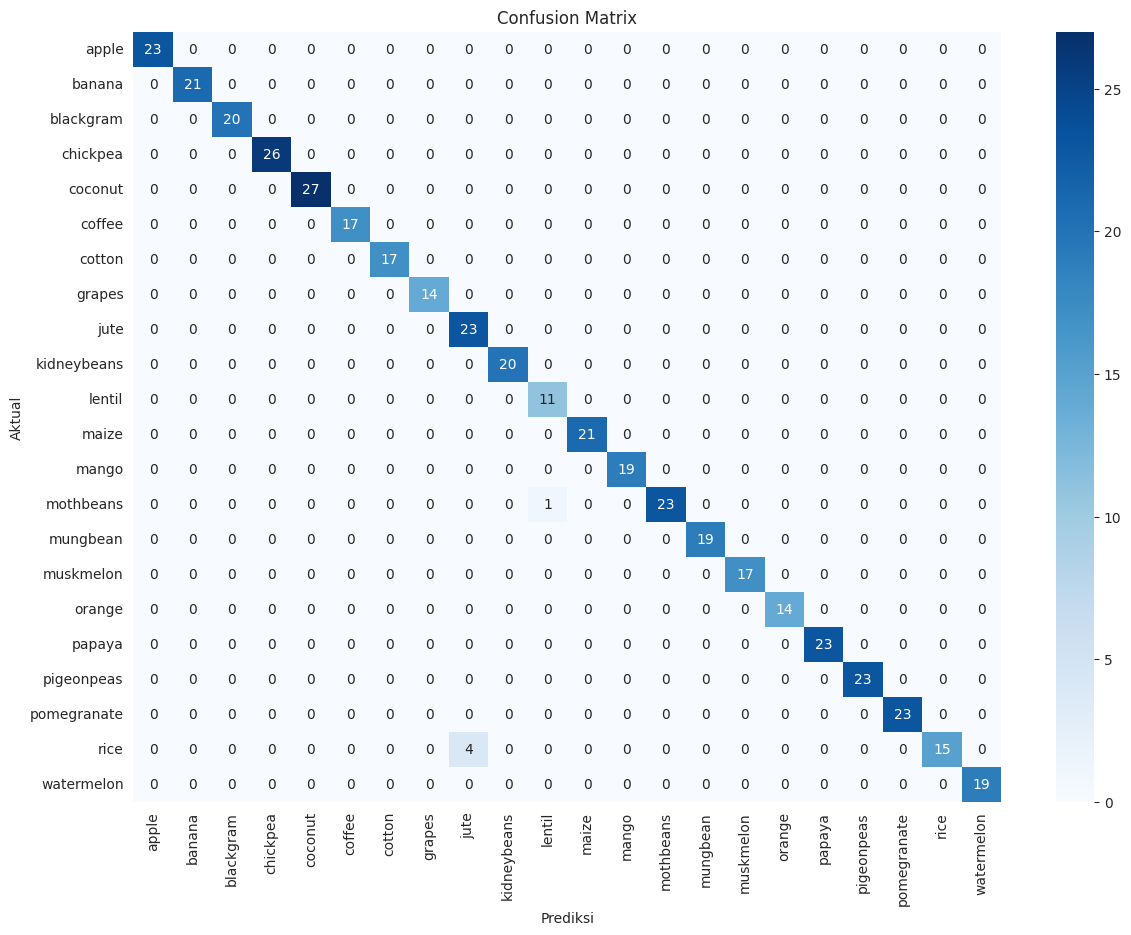

In [ ]:
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

**Simpan Model**

In [ ]:
joblib.dump(rf_model, 'model_rekomendasi_tanaman.pkl')
print("Model berhasil disimpan.")

Model berhasil disimpan.


**Simulasi Prediksi Data Baru**

In [ ]:
data_baru = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]])
data_baru = data_baru[:, :len(selected_features)]

prediksi = rf_model.predict(data_baru)

print("Data baru:", data_baru)
print("Rekomendasi tanaman:", prediksi[0])

Data baru: [[90.  42.  43.  20.8 82. ]]
Rekomendasi tanaman: chickpea
